# CRC gene expression across distance from the tumor

This notebook reproduces the three distance-ranked heatmaps used to examine expression layering at the CRC tumor periphery. Spot ordering, gene selection, expression recovery, and the 100-pixel inclusion threshold match the manuscript analysis; the x-axis reports the sample-specific physical distance in microns.

**Data source:** Human colorectal cancer Visium HD datasets from [10x Genomics](https://www.10xgenomics.com/resources/datasets).

## Paths and plotting entry point

In [ ]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Image, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = Path("../..").resolve()
SCRIPT = REPO_ROOT / "scripts/crc_visium_hd/make_crc_gene_distance_heatmaps.py"
H5AD = REPO_ROOT / "results/visium-hd/cancer_tumor_regions.h5ad"
OUTPUT_DIR = REPO_ROOT / "workflows/crc_gene_distance_heatmaps"


## Generate the heatmaps

The plotting script applies an explicit, isolated Matplotlib style and checks version-dependent `imshow` arguments before rendering. This prevents global rcParams or an older Matplotlib release from changing the intended colormap and normalization.

In [ ]:
subprocess.run(
    [
        sys.executable,
        str(SCRIPT),
        "--h5ad",
        str(H5AD),
        "--outdir",
        str(OUTPUT_DIR),
    ],
    check=True,
)


## Reproduced heatmaps

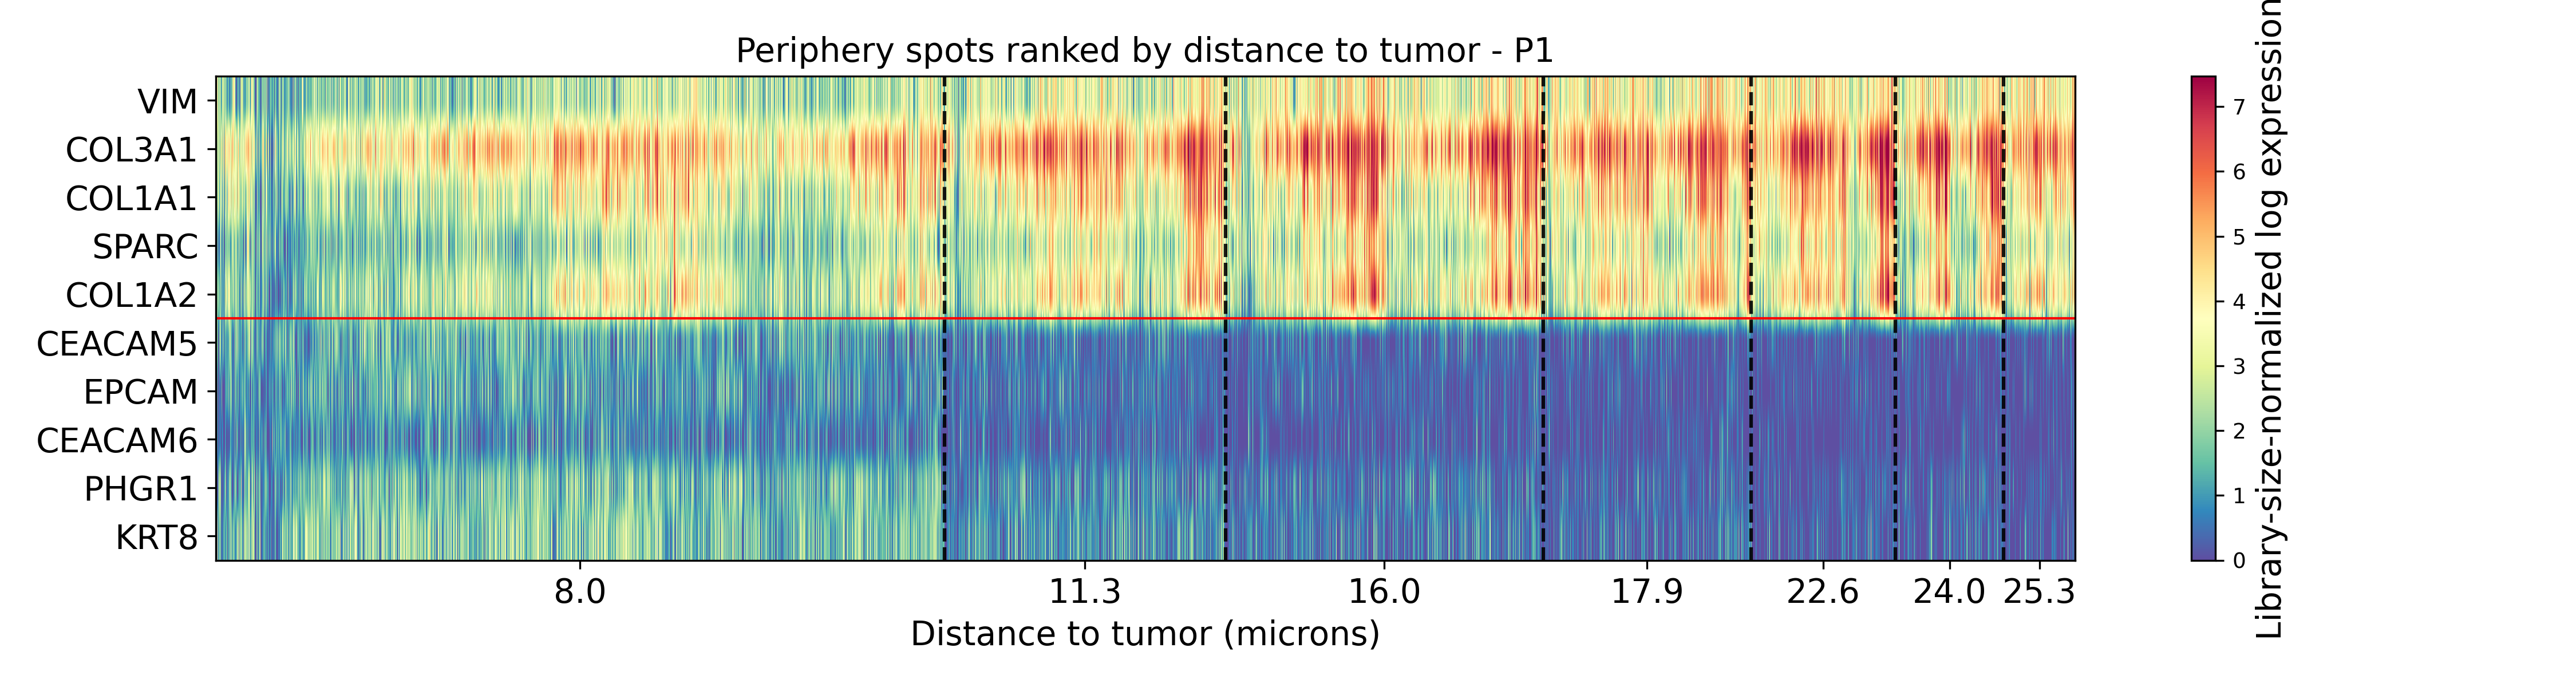

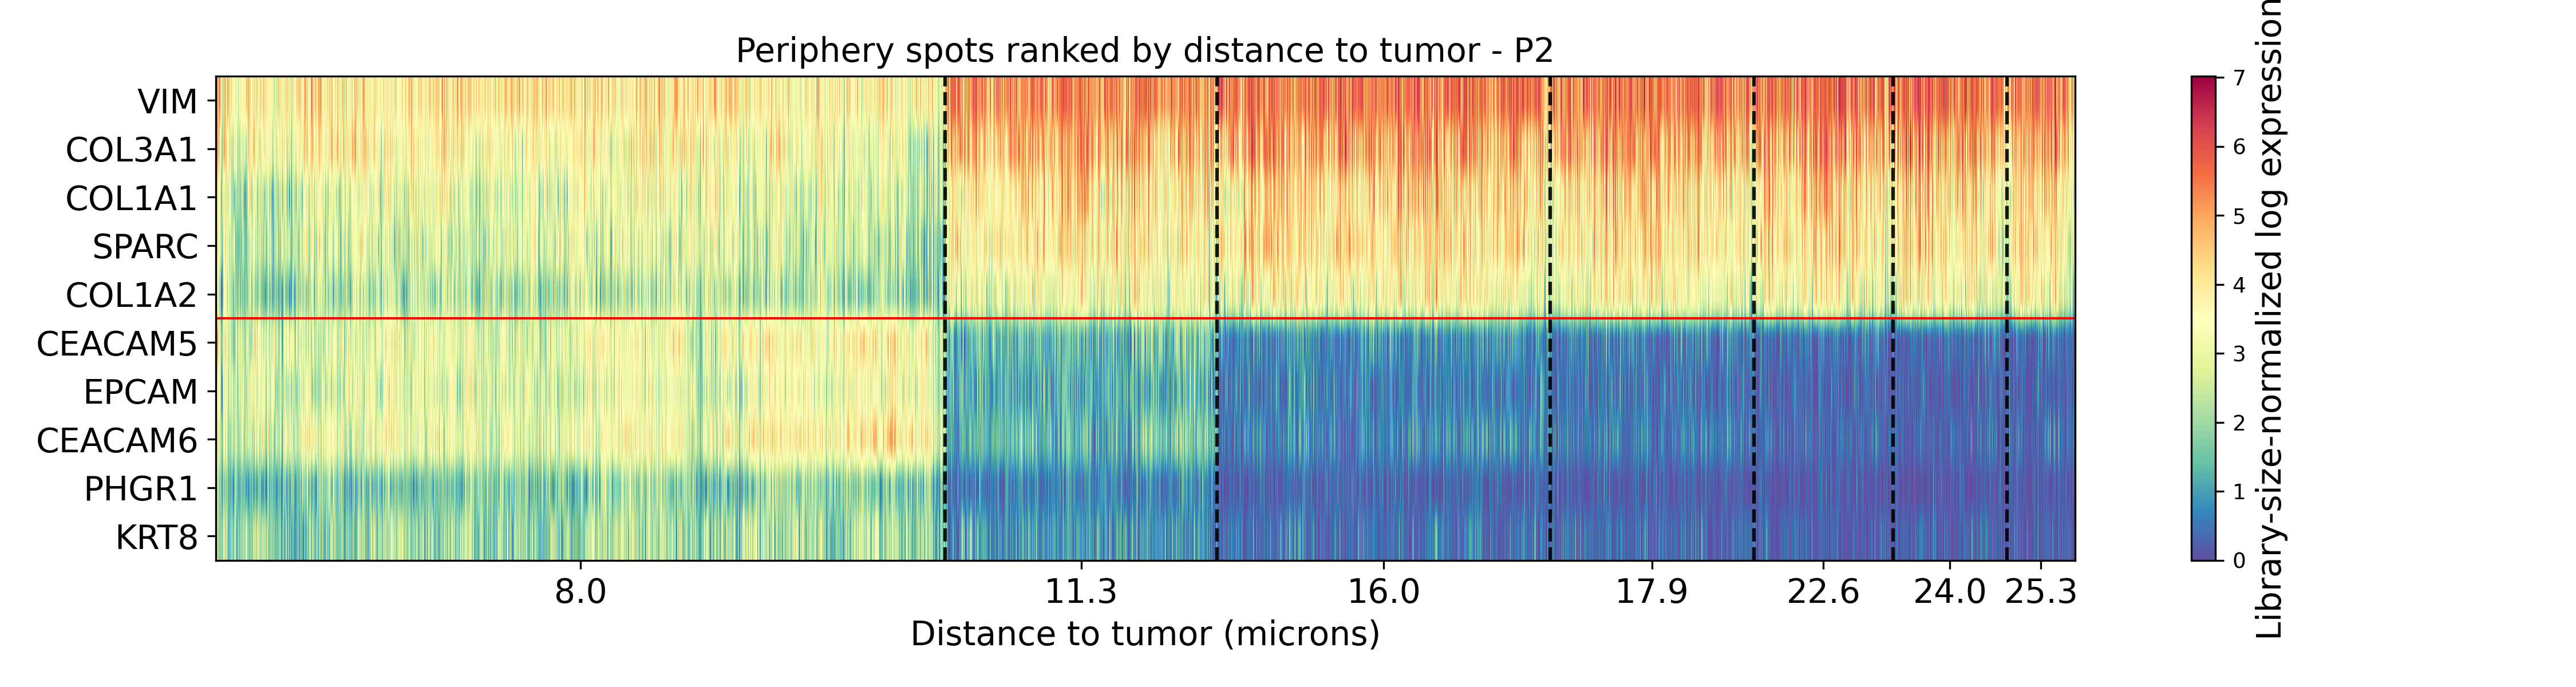

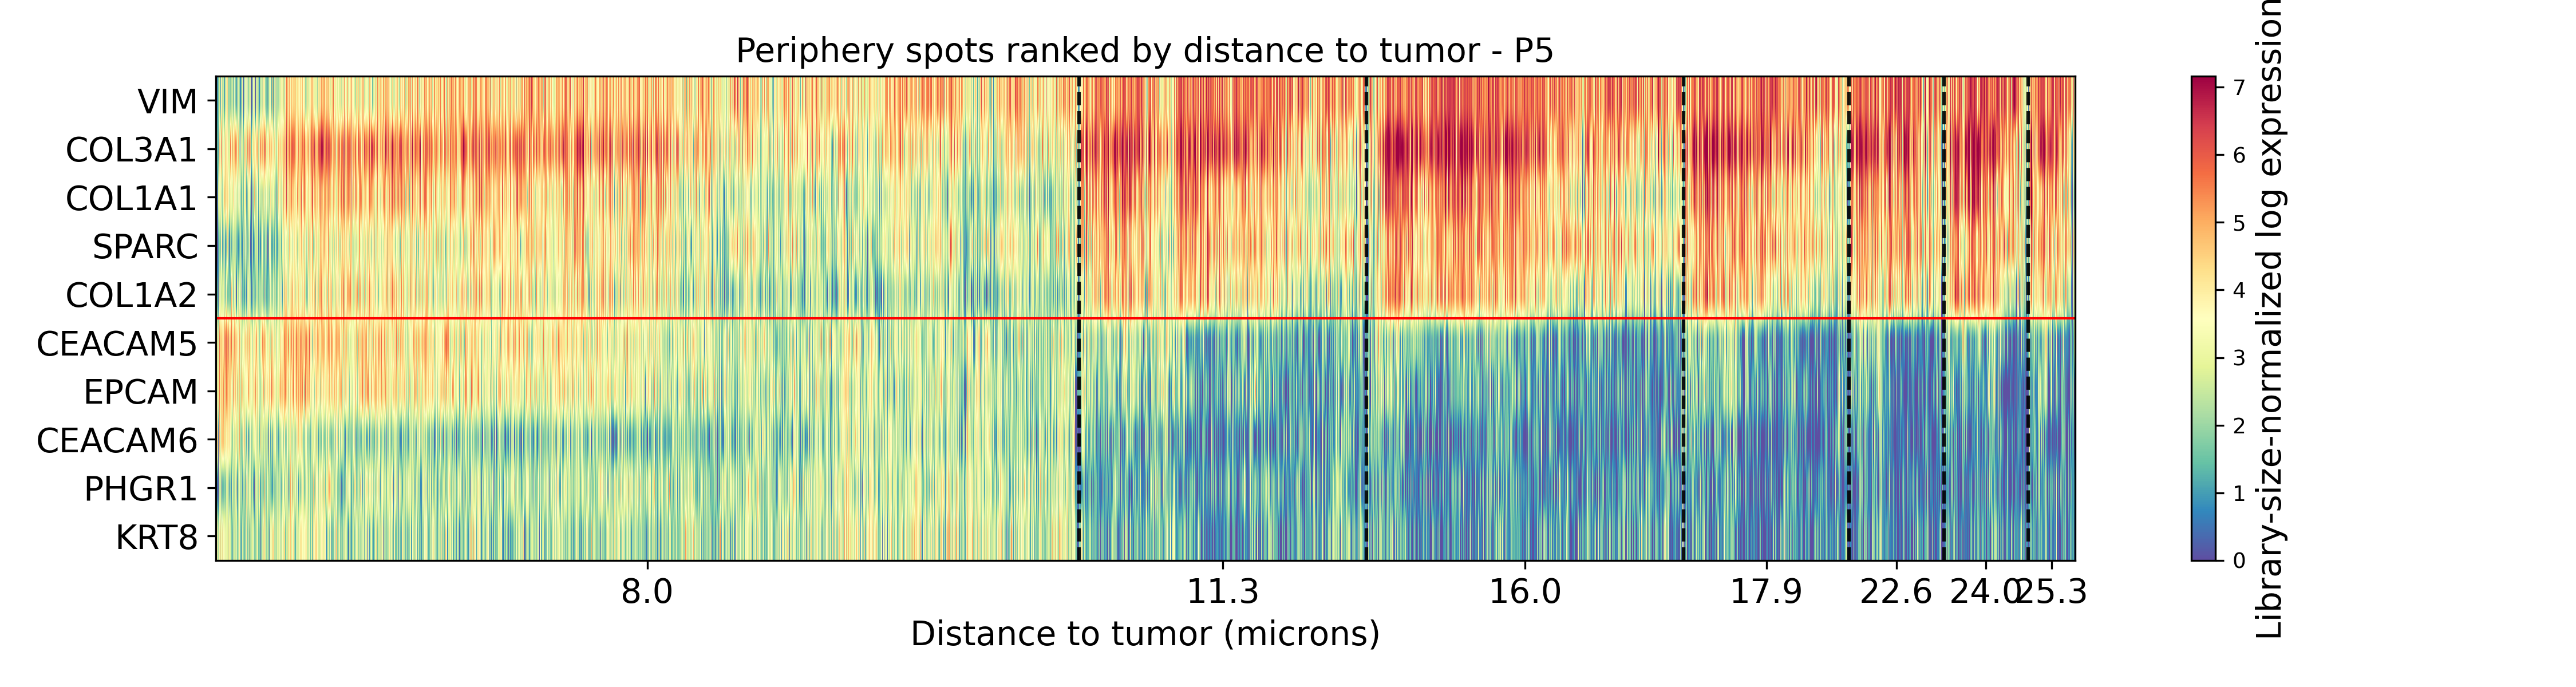

In [1]:
for sample in ("p1", "p2", "p5"):
    display(
        Image(
            filename=OUTPUT_DIR
            / f"cancer_{sample}_periphery_vs_tumor_distance_corrected.png"
        )
    )


The first five rows are stromal/periphery-associated genes and the last five rows are epithelial/tumor-associated genes. Dashed vertical lines separate physical-distance shells after stable sorting of periphery spots.